In [1]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

In [2]:
# Generate synthetic time series data
def generate_time_series_data(num_samples, seq_length):
   x = np.linspace(0, 10, num_samples)
   y = np.sin(x) + np.random.normal(0, 0.1, num_samples)

   X, Y= [], []
   for i in range(len(y) - seq_length):
     X.append(y[i:i+seq_length])
     Y.append(y[i+seq_length])

   return np.array(X), np.array(Y)

In [3]:
# parameters
seq_length = 10
num_samples = 200

# Prepare the data
X_raw, Y_raw = generate_time_series_data(num_samples, seq_length)

X_raw

array([[-0.02164767,  0.12097635,  0.13649264, ...,  0.54456177,
         0.40664037,  0.43340772],
       [ 0.12097635,  0.13649264,  0.2390273 , ...,  0.40664037,
         0.43340772,  0.53221031],
       [ 0.13649264,  0.2390273 ,  0.17621711, ...,  0.43340772,
         0.53221031,  0.30634831],
       ...,
       [ 0.19536957,  0.03624419,  0.10582108, ..., -0.37741804,
        -0.26195132, -0.34724946],
       [ 0.03624419,  0.10582108, -0.08071668, ..., -0.26195132,
        -0.34724946, -0.42834738],
       [ 0.10582108, -0.08071668, -0.03646193, ..., -0.34724946,
        -0.42834738, -0.53847557]], shape=(190, 10))

In [4]:
# Split Train/Test
X_reshaped = X_raw.reshape(X_raw.shape[0], X_raw.shape[1], 1)

train_size = int(0.8 * len(X_reshaped))
X_train, X_test = X_reshaped[:train_size], X_reshaped[train_size:]
Y_train, Y_test = Y_raw[:train_size], Y_raw[train_size:]

In [5]:
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (152, 10, 1)
Testing data shape: (38, 10, 1)


## Buildthe GRU Model

In [6]:
model = Sequential()
model.add(GRU(units=50, return_sequences=False, input_shape=(seq_length, 1)))
model.add(Dense(units=1))

c:\Users\saromiya\Desktop\my_proof\project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train the model
history = model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - loss: 0.7133 - val_loss: 1.0212
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5276 - val_loss: 0.7030
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3727 - val_loss: 0.4559
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2448 - val_loss: 0.2575
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1442 - val_loss: 0.1048
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0693 - val_loss: 0.0321
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0380 - val_loss: 0.0312
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0410 - val_loss: 0.0366
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0454 - val_loss: 0.0275
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0390 - val_loss: 0.0245
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0325 - val_loss: 0.0241
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0313 - val_loss: 0.0252


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step


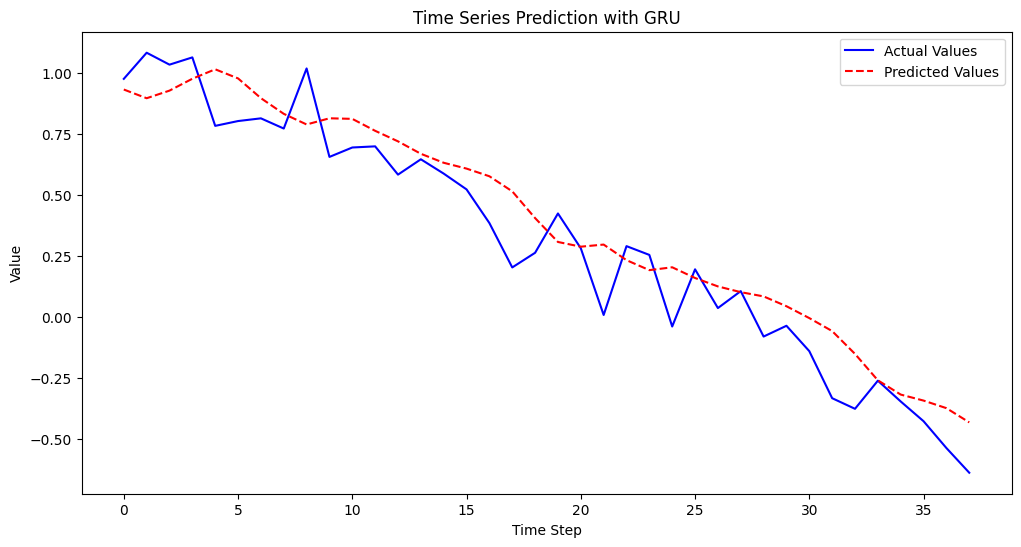

In [9]:
# Make predictions on the test set
predictions = model.predict(X_test)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(Y_test, label='Actual Values', color='blue')
plt.plot(predictions, label='Predicted Values', color='red', linestyle='dashed')
plt.title('Time Series Prediction with GRU')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()